In [1]:
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch

In [2]:
DATA_DIR = "data/cats/CAT_0"
OUTPUT_DIR = "data_output/cats"
MARGIN_RATIO = 0.3
TARGET_SIZE = 64

In [3]:

import math
def process_images():
    os.makedirs(OUTPUT_DIR, exist_ok = True)
    for i in range(7):
        data_dir = DATA_DIR + str(i)
        print(f"Processing images in {data_dir}")
        for filename in os.listdir(data_dir):
            if not filename.endswith(".jpg"):
                continue 
            img_path = os.path.join(data_dir , filename)
            cat_info_path = img_path + ".cat"

            if not os.path.exists(cat_info_path):
                print(f"File {cat_info_path} does not exist.")
                continue

            with open(cat_info_path, "r") as f:
                cat_info = list(map(int, f.read().split()))

            points = cat_info[1:]
            left_eye_x, left_eye_y = points[0], points[1]
            right_eye_x, right_eye_y = points[2], points[3]
            mouth_x, mouth_y = points[4], points[5]

            # rotation 
            dy = right_eye_y - left_eye_y
            dx = right_eye_x - left_eye_x

            angle = math.degrees(math.atan2(dy, dx))
            xs = points[0::2]
            ys = points[1::2]

            min_x, max_x = min(xs), max(xs)
            min_y, max_y = min(ys), max(ys)

            face_center_x = (min_x + max_x) // 2
            face_center_y = (min_y + max_y) // 2

            face_width = max_x - min_x
            face_height = max_y - min_y
            box_size = int(max(face_width, face_height) * (1 + MARGIN_RATIO))

            with Image.open(img_path) as img:
                img = img.convert("RGB")

                rotated_img = img.rotate(angle, center=(face_center_x, face_center_y), resample=Image.Resampling.BICUBIC)
                left = face_center_x - (box_size // 2)
                top = face_center_y - (box_size // 2)
                right = face_center_x + (box_size // 2)
                bottom = face_center_y + (box_size // 2)

                cropped_img = rotated_img.crop((left, top, right, bottom))
                final_img = cropped_img.resize(size=(TARGET_SIZE, TARGET_SIZE), resample=Image.Resampling.BILINEAR)

                save_path = os.path.join(OUTPUT_DIR, filename)
                final_img.save(save_path, quality=95)
    


In [4]:
process_images()

Processing images in data/cats/CAT_00
Processing images in data/cats/CAT_01
Processing images in data/cats/CAT_02
Processing images in data/cats/CAT_03
Processing images in data/cats/CAT_04
Processing images in data/cats/CAT_05
Processing images in data/cats/CAT_06


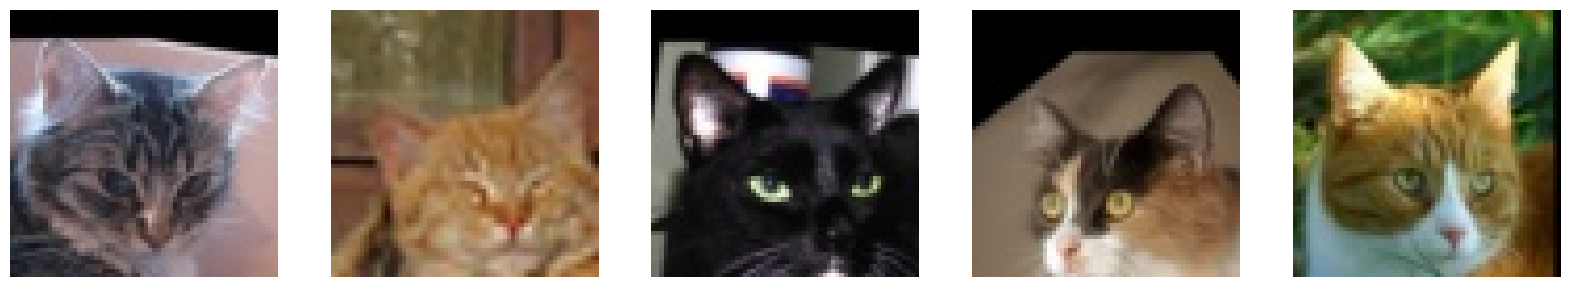

In [26]:
image_files = [
    file for file in os.listdir(OUTPUT_DIR) if file.endswith((".jpg", ".jpeg", ".png"))
]
num_images_to_plot = 5
fig, axes = plt.subplots(1, num_images_to_plot, figsize=(20, 5))

for i, file in enumerate(image_files[:num_images_to_plot]):
    # Read image using OpenCV
    img_path = os.path.join(OUTPUT_DIR, file)
    try:
        img = cv2.imread(img_path)

        # Check if image is empty
        if img is None:
            raise Exception(f"Unable to read image: {img_path}")

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Plot the image
        axes[i].imshow(img)
        axes[i].axis("off")
    except Exception as e:
        print(f"Error processing image: {img_path} - {e}")

plt.show()

In [27]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [46]:
# Root directory for dataset
dataroot = "data_output"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = TARGET_SIZE

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 50

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

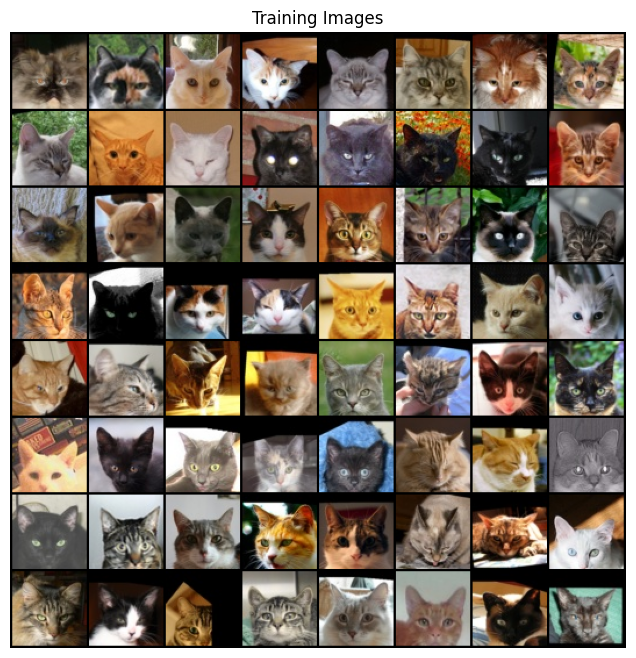

In [29]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on
device = torch.device("mps" if (torch.mps.is_available() and ngpu > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [37]:
from torch import nn


class Generator(nn.Module):
    def __init__(self, n_gpu: int):
        super(Generator, self).__init__()
        self.n_gpu = n_gpu

        self.main = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=nz,
                out_channels=ngf * 8,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ngf * 8),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                in_channels=ngf * 8,
                out_channels=ngf * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ngf * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                in_channels=ngf * 4,
                out_channels=ngf * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ngf * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                in_channels=ngf * 2,
                out_channels=ngf,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ngf),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(
                in_channels=ngf,
                out_channels=nc,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.Tanh(),
        )

    def forward(self, input: torch.Tensor):
        return self.main(input)

In [38]:
class Discriminator(nn.Module):
    def __init__(self, n_gpu: int):
        super(Discriminator, self).__init__()
        self.n_gpu = n_gpu

        self.main = nn.Sequential(
            nn.Conv2d(
                in_channels=nc,
                out_channels=ndf,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(
                in_channels=ndf,
                out_channels=ndf * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ndf * 2),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(
                in_channels=ndf * 2,
                out_channels=ndf * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ndf * 4),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(
                in_channels=ndf * 4,
                out_channels=ndf * 8,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(num_features=ndf*8),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(
                in_channels=ndf * 8,
                out_channels=1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.Sigmoid(),
        )

    def forward(self, input: torch.Tensor):
        return self.main(input)

In [39]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [65]:
# Create the generator
print(f"DEBUG: nc = {nc}, ndf = {ndf}")
netG = Generator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

DEBUG: nc = 3, ndf = 64
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)

In [66]:
# Create the Discriminator
print(f"DEBUG: nc = {nc}, ndf = {ndf}")
netD = Discriminator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

DEBUG: nc = 3, ndf = 64
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [67]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1
fake_label = 0

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))


In [68]:
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting training loop...")
num_epochs = 100
for epoch in range(num_epochs):

    for i, data in enumerate(dataloader, 0):
        # 1 Update D netowork (maximize log(D(x)) + log(1 -D(G(z)))
        # train batch of real images
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full(
            size=(b_size,), fill_value=real_label, dtype=torch.float, device=device
        )
        output = netD(real_cpu).view(-1)

        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # train batch with fake images
        # batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # generate fake images with G
        fake = netG(noise)
        label.fill_(fake_label)
        # classify fake batch with D
        output = netD(fake.detach()).view(-1)
        # calculate D's loss on the fake batch
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        # 2. Update G network maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        if i % 50 == 0:
            print(
                "[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f"
                % (
                    epoch,
                    num_epochs,
                    i,
                    len(dataloader),
                    errD.item(),
                    errG.item(),
                    D_x,
                    D_G_z1,
                    D_G_z2,
                )
            )

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if (iters % 500 == 0) or (
            (epoch == num_epochs - 1) and (i == len(dataloader) - 1)
        ):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting training loop...
[0/100][0/79]	Loss_D: 1.9044	Loss_G: 5.2052	D(x): 0.4242	D(G(z)): 0.4886 / 0.0084
[0/100][50/79]	Loss_D: 0.1515	Loss_G: 6.6766	D(x): 0.9750	D(G(z)): 0.1128 / 0.0021
[1/100][0/79]	Loss_D: 0.1457	Loss_G: 17.6118	D(x): 0.9134	D(G(z)): 0.0000 / 0.0000
[1/100][50/79]	Loss_D: 1.9389	Loss_G: 3.5310	D(x): 0.3999	D(G(z)): 0.0595 / 0.0624
[2/100][0/79]	Loss_D: 0.4538	Loss_G: 4.4090	D(x): 0.7379	D(G(z)): 0.0324 / 0.0294
[2/100][50/79]	Loss_D: 0.2457	Loss_G: 4.5877	D(x): 0.9058	D(G(z)): 0.1140 / 0.0147
[3/100][0/79]	Loss_D: 0.6185	Loss_G: 7.8986	D(x): 0.9227	D(G(z)): 0.1957 / 0.0034
[3/100][50/79]	Loss_D: 0.2931	Loss_G: 5.1102	D(x): 0.8825	D(G(z)): 0.0700 / 0.0140
[4/100][0/79]	Loss_D: 1.1908	Loss_G: 4.8705	D(x): 0.8240	D(G(z)): 0.3917 / 0.0403
[4/100][50/79]	Loss_D: 0.6932	Loss_G: 3.4500	D(x): 0.7669	D(G(z)): 0.2348 / 0.0574
[5/100][0/79]	Loss_D: 0.5162	Loss_G: 3.0519	D(x): 0.7678	D(G(z)): 0.1238 / 0.0741
[5/100][50/79]	Loss_D: 0.4428	Loss_G: 3.2221	D(x): 0.7817	D(G(z)):

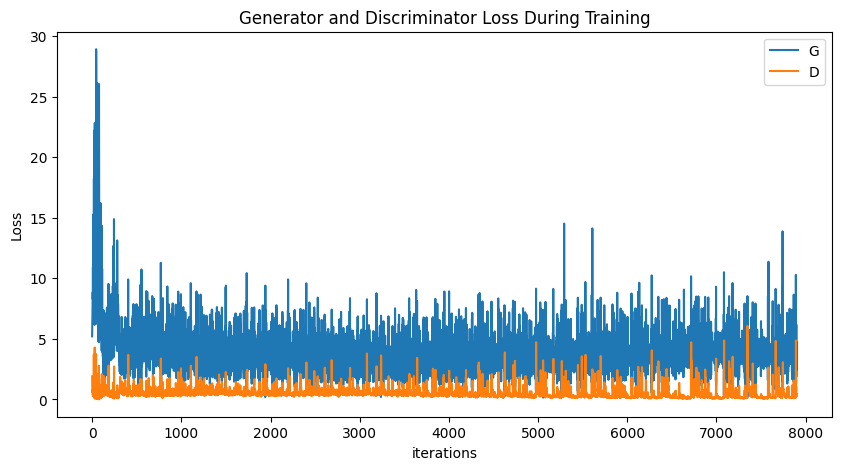

In [71]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

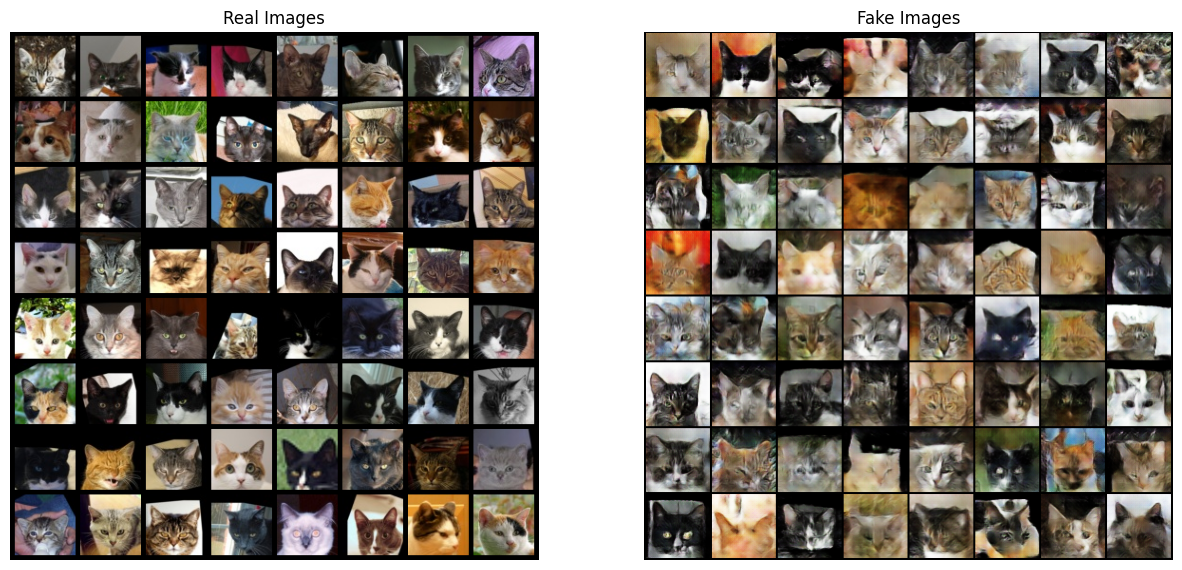

In [72]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()